# spatial statistics

In [1]:
# %% Libraries
import os
import squidpy as sq
import scanpy as sc
#import scvi
import numpy as np
from pathlib import Path
import pandas as pd
#import novae
import matplotlib.pyplot as plt
import rapids_singlecell as rsc

import os
#import plotnine as p9

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
CUR_OBJ_V = 'cellcharter'
CUR_OBJ_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{CUR_OBJ_V}.h5ad'

# %% Load the object
comb = sc.read_h5ad(CUR_OBJ_PATH)


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
comb

AnnData object with n_obs × n_vars = 1187341 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_

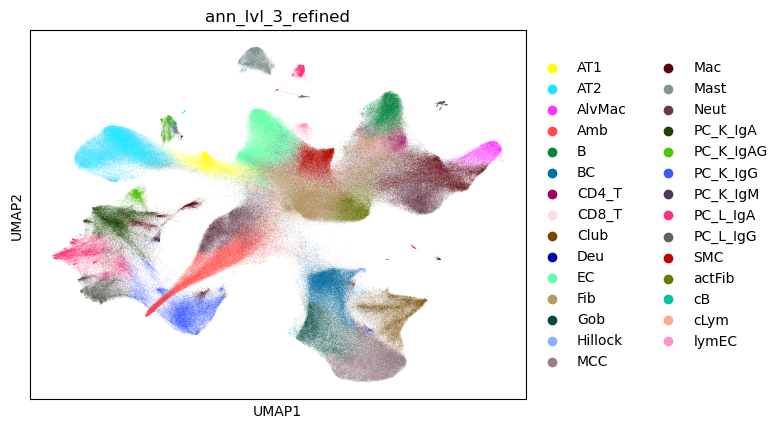

In [3]:
sc.pl.umap(comb, color='ann_lvl_3_refined')

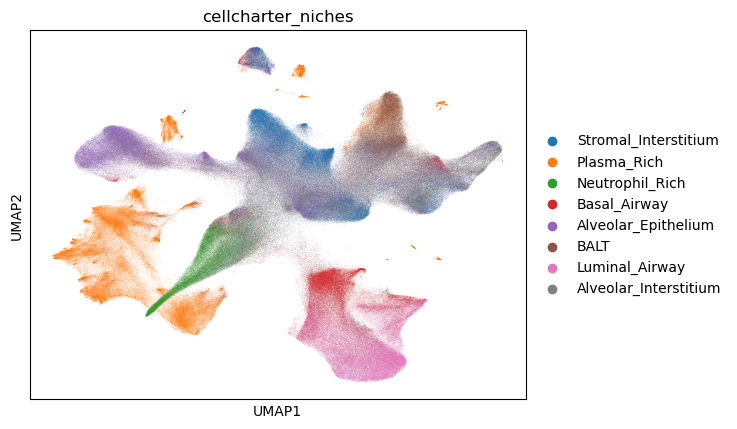

In [4]:
sc.pl.umap(
    comb,
    color='cellcharter_niches'
)

## Try for one sample

In [3]:
adata = comb[comb.obs['sample_name']=='PWCF01_1']

## Calculate spatial neighbors

In [4]:
## NOTE: use the offset coords

# KNN graph
sq.gr.spatial_neighbors_knn(
    adata,
    n_neighs=10,
    key_added="knn",
    spatial_key="X_spatial"
)

# Delaunay graph
sq.gr.spatial_neighbors_delaunay(
    adata,
    key_added="delaunay",
    spatial_key="X_spatial"
)

adata

INFO     Creating graph using `None` transform and `1` libraries.                                                  


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/squidpy/gr/_utils.py:79: ImplicitModificationWarning: Setting element `.obsp['knn_connectivities']` of view, initializing view as actual.
  obj[key] = data


INFO     Creating graph using `None` transform and `1` libraries.                                                  


AnnData object with n_obs × n_vars = 170618 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_6

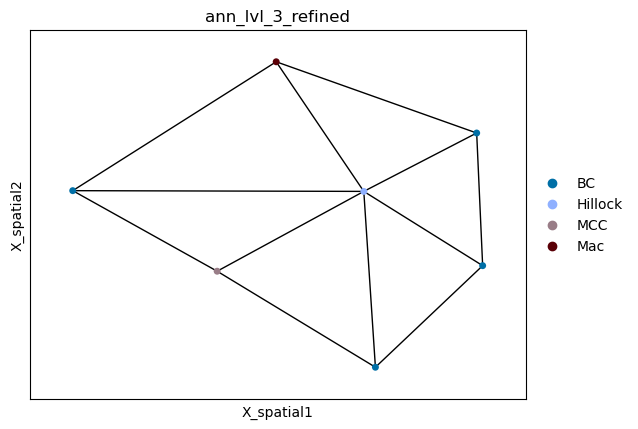

In [5]:
# check 10 closest neightbors for one hillock cell

hillock_idx = np.flatnonzero(
    adata.obs["ann_lvl_3_refined"].values == "Hillock"
)

hillock_idx[:10]

cell_idx = hillock_idx[5]

_, idx = adata.obsp[
    "delaunay_connectivities"
][cell_idx, :].nonzero()

idx = np.append(idx, cell_idx)

sub = adata[idx].copy()

sc.pl.embedding(
    sub,
    basis="X_spatial",
    color="ann_lvl_3_refined",
    edges=True,
    neighbors_key="delaunay_neighbors",
    size=100,
    edges_width=1,
    edges_color="black",
)

## Centrality Scores

In [6]:
sq.gr.centrality_scores(
    adata, 
    cluster_key="ann_lvl_3_refined", 
    connectivity_key='delaunay_connectivities'
)

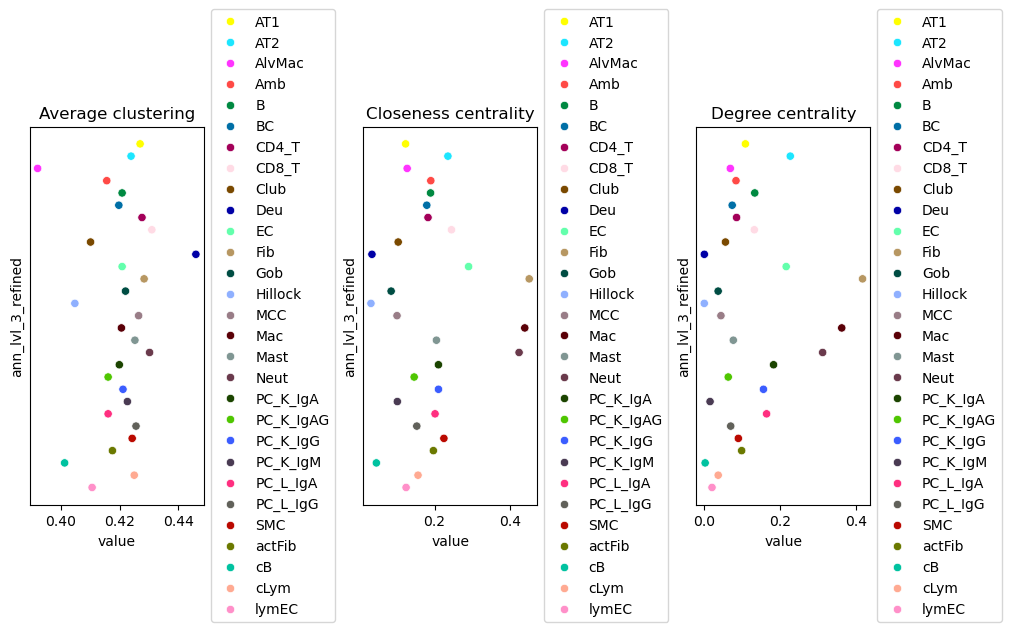

In [7]:
sq.pl.centrality_scores(
    adata, 
    cluster_key="ann_lvl_3_refined", 
    figsize=(10, 6)
)

## Compute co-ocurrence probability

Processing PWCF06


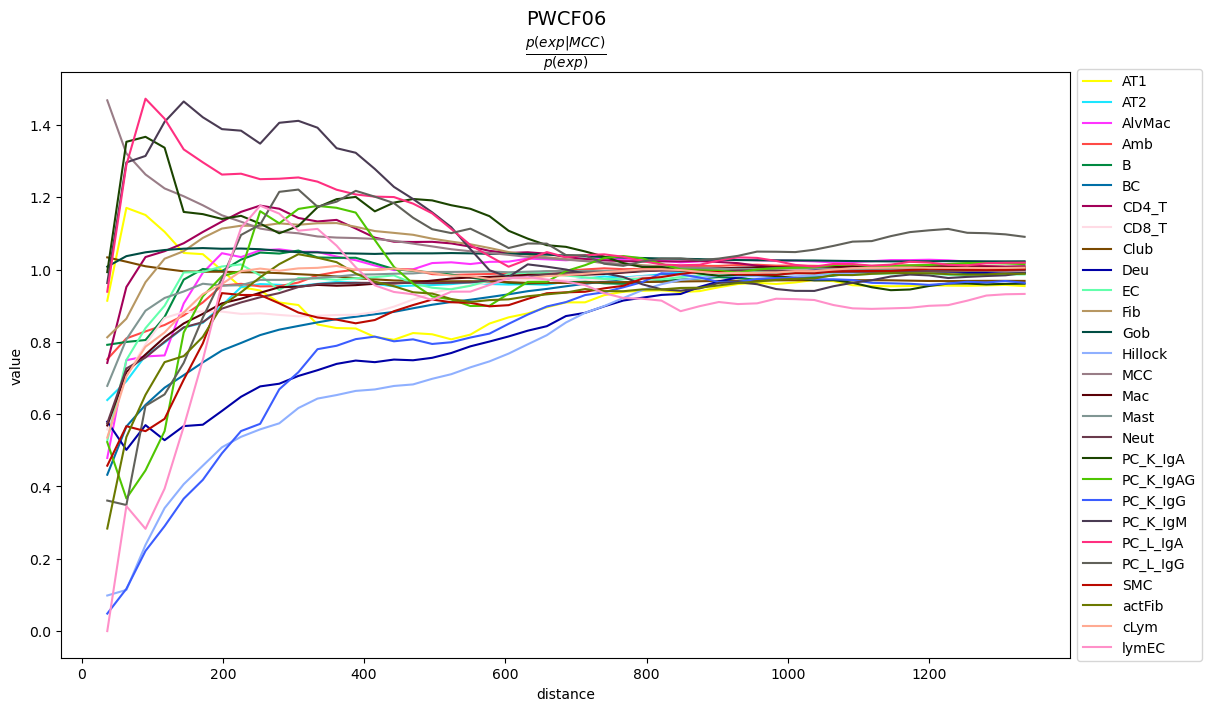

Processing PWCF01_2


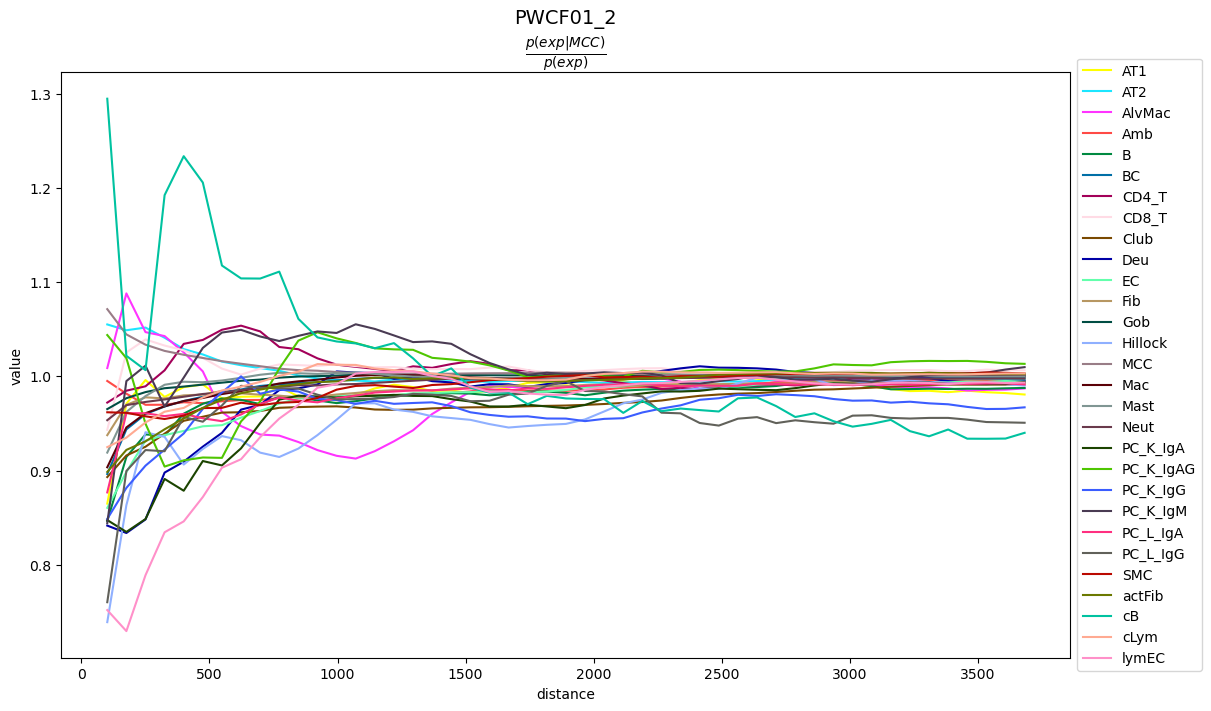

Processing CTRL05


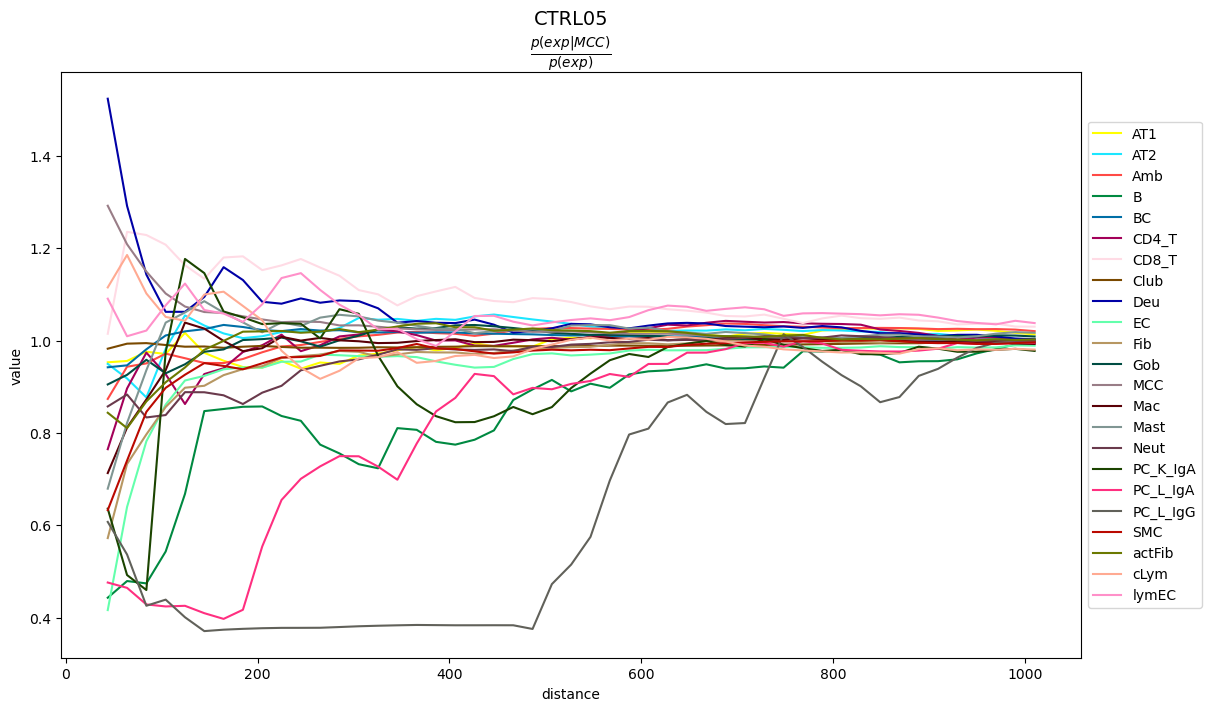

Processing CTRL02


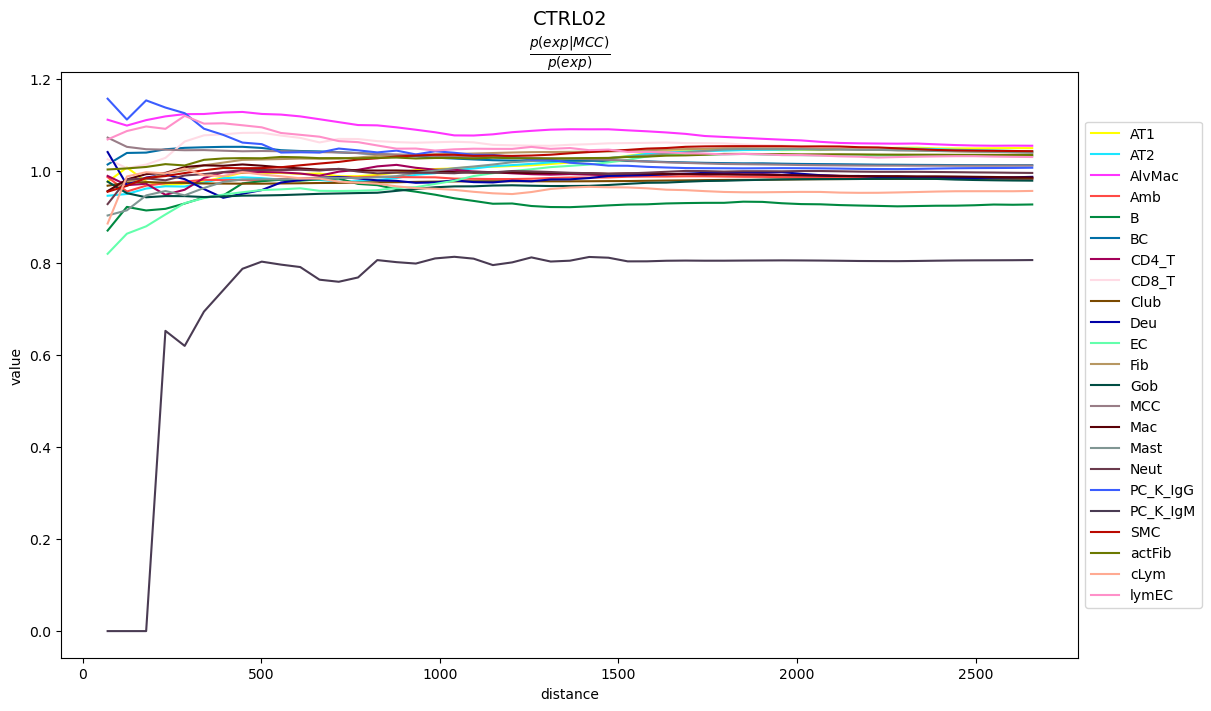

Processing PWCF04


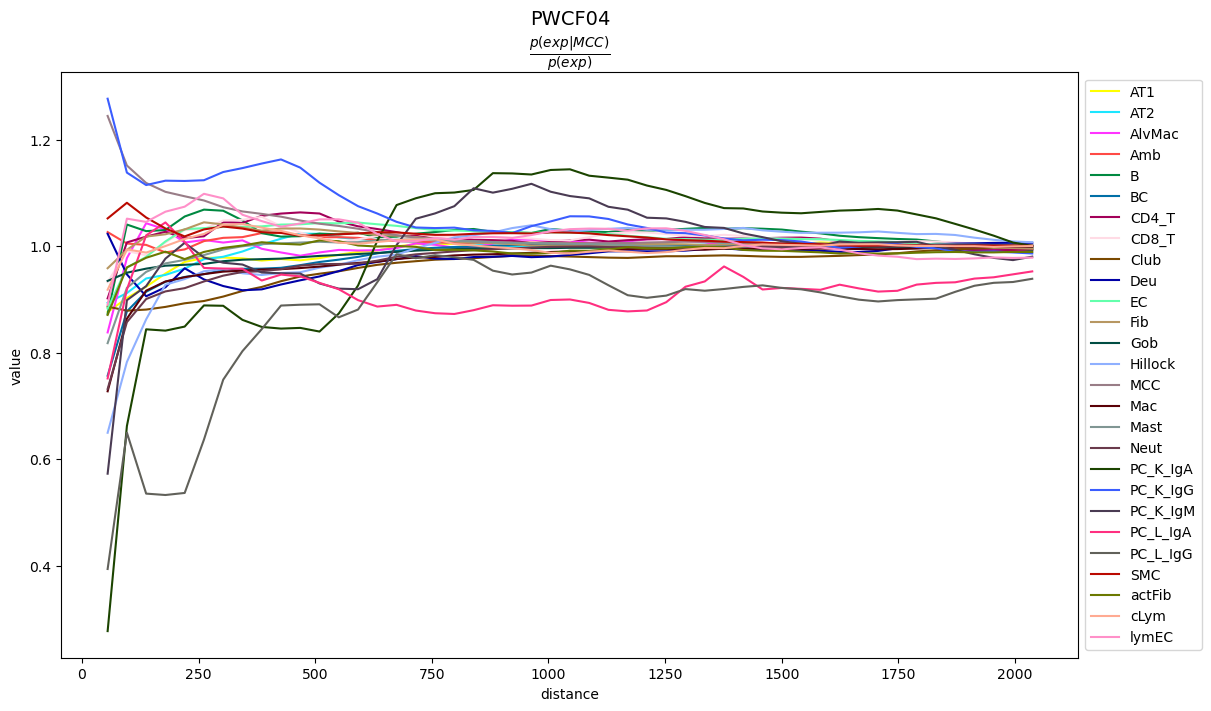

Processing CTRL01


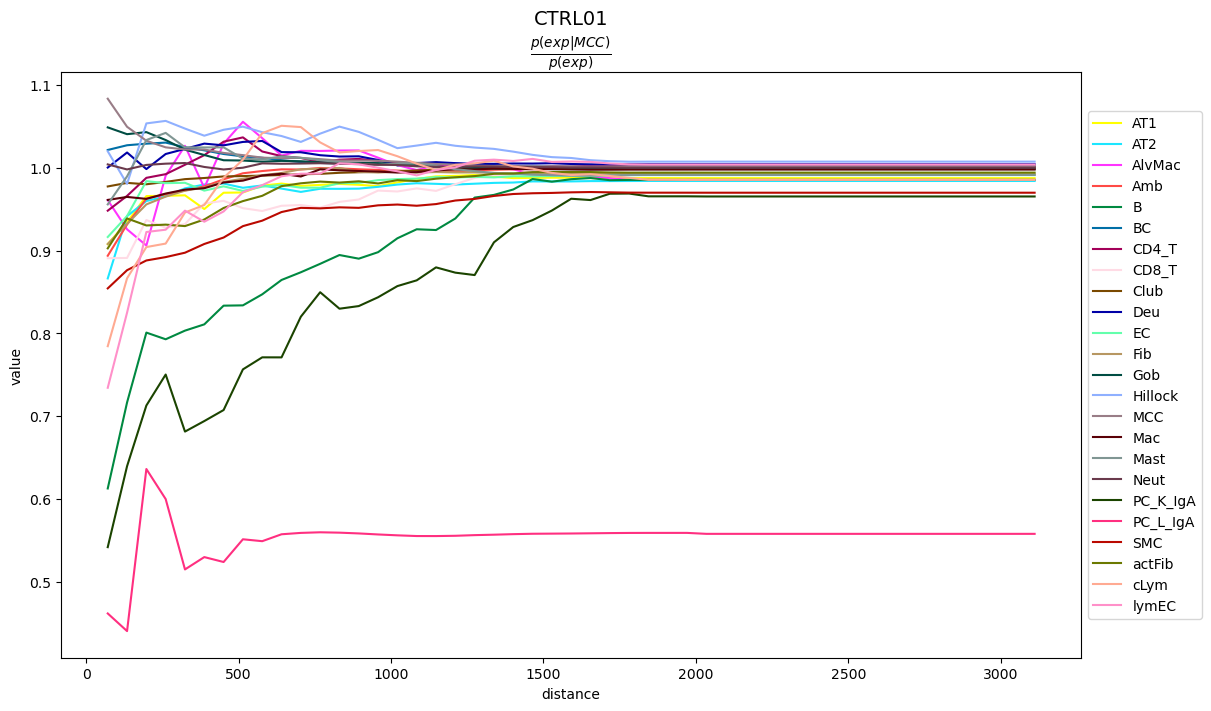

Processing CTRL04


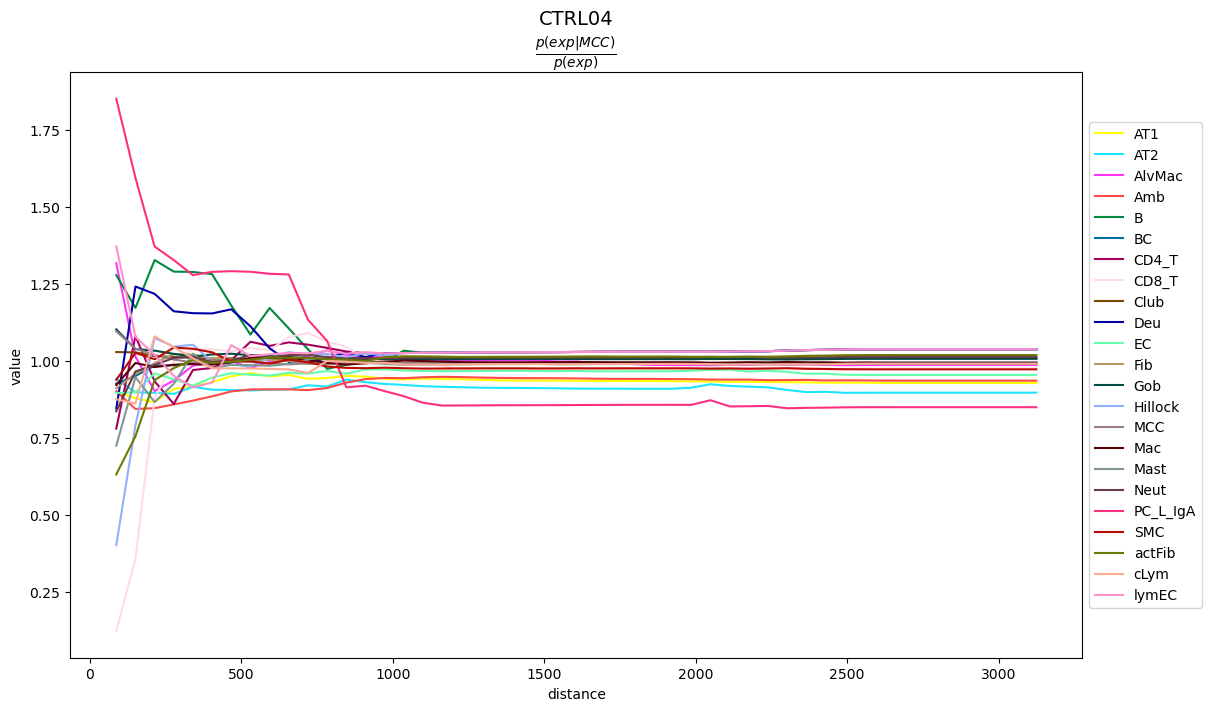

Processing PWCF03


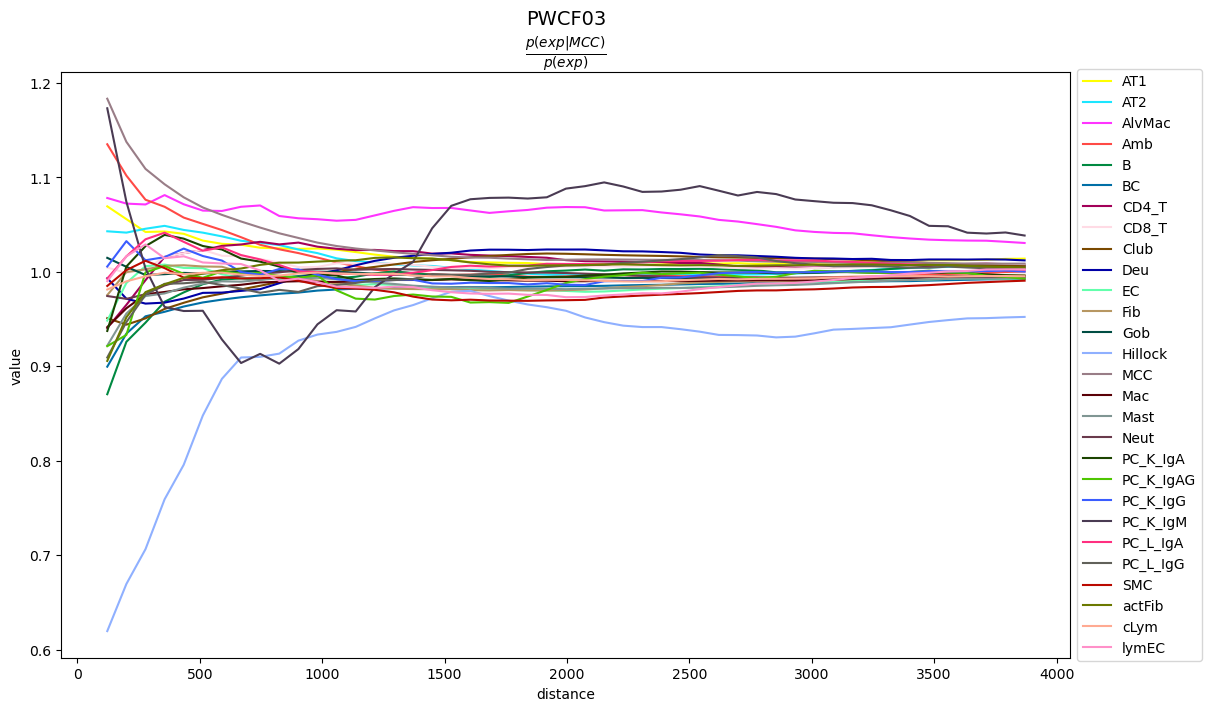

Processing PWCF01_1


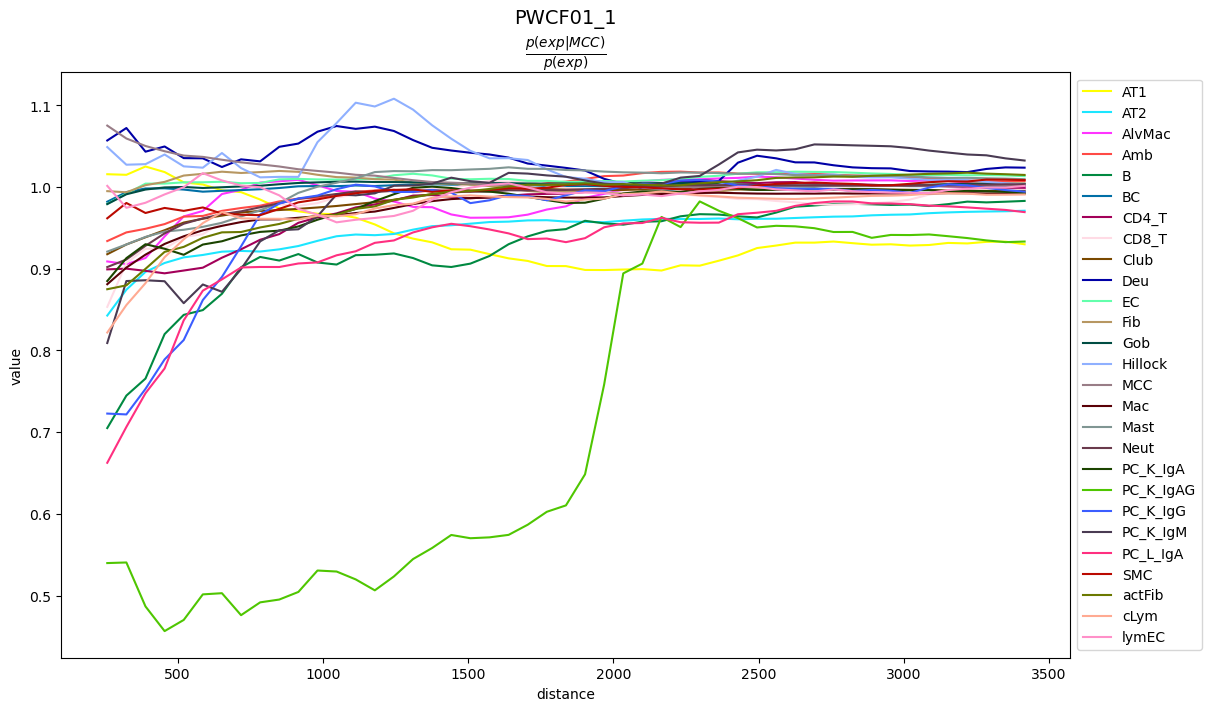

Processing PWCF05


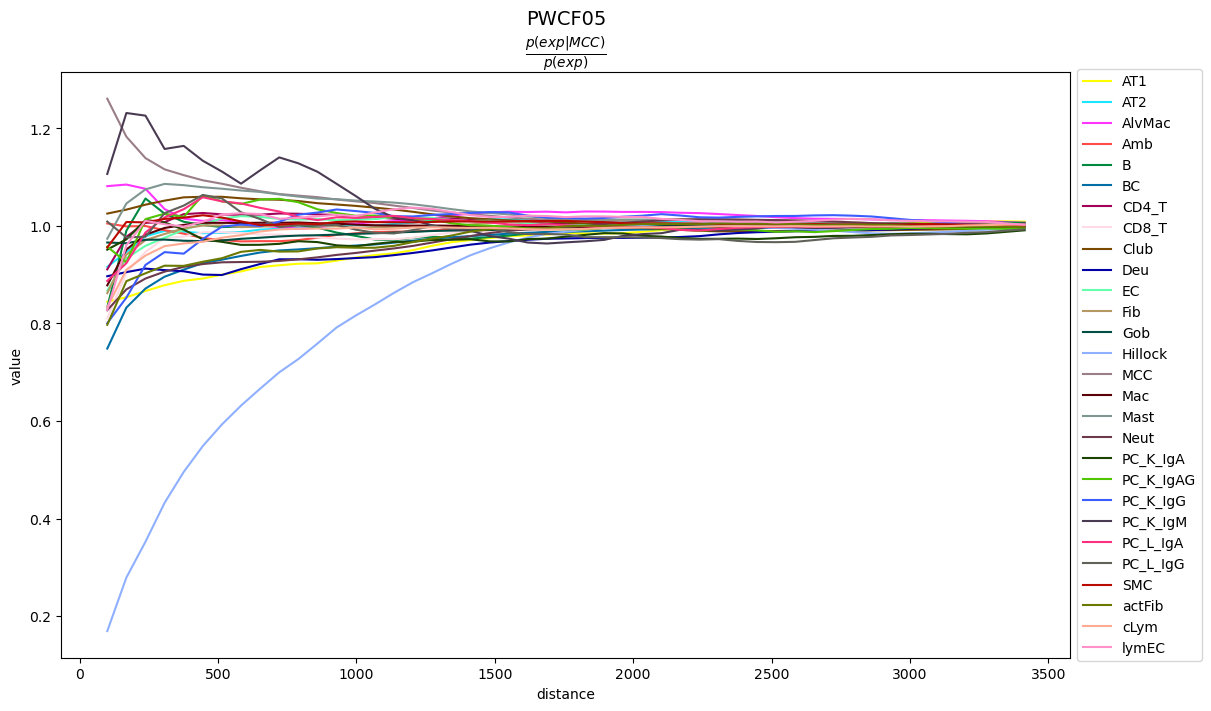

Processing CTRL03


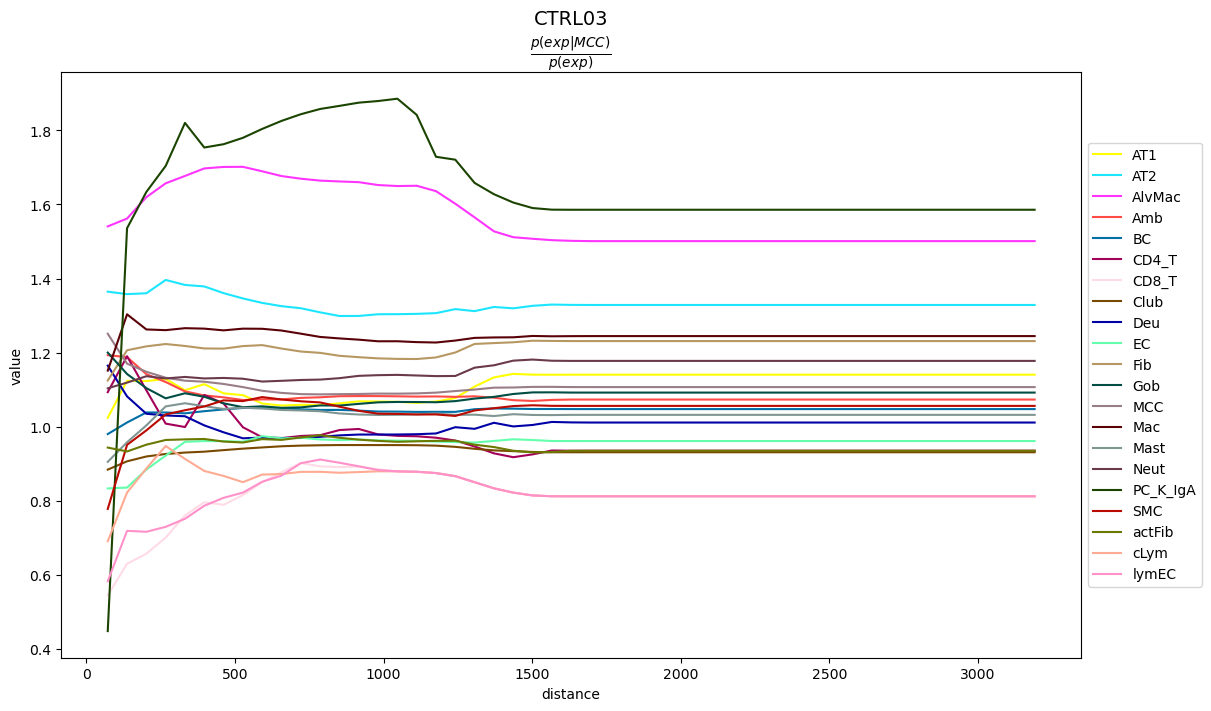

Processing PWCF02


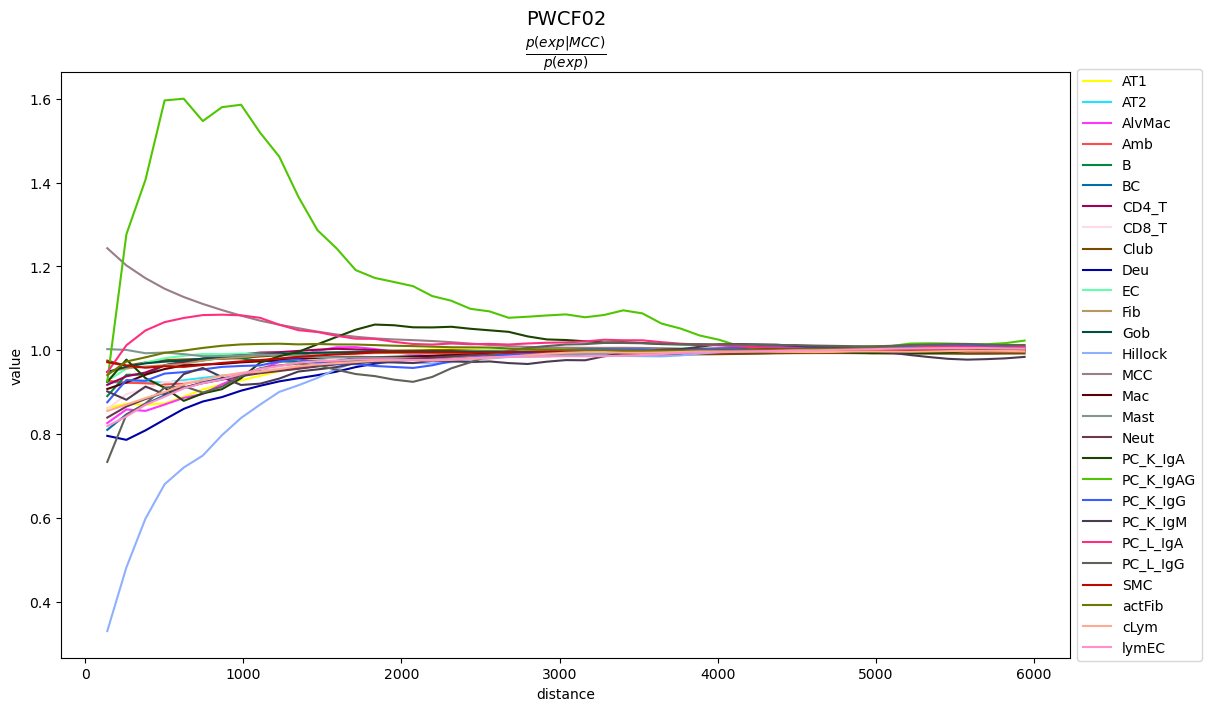

In [17]:
import matplotlib.pyplot as plt

sample_list = comb.obs["sample_name"].unique()
ct = 'Hillock'

for sample in sample_list:

    print(f"Processing {sample}")

    try:
        adata_sample = comb[
            (comb.obs["sample_name"] == sample) &
            (comb.obs["niche_name"] == "airway_epithelium")
        ].copy()
    

        # Skip samples without Hillock cells
        if ct not in adata_sample.obs["ann_lvl_3_refined"].values:
            print(f"Skipping {sample}: no Hillock cells")
            continue

        rsc.gr.co_occurrence(
            adata_sample,
            spatial_key="spatial",
            cluster_key="ann_lvl_3_refined",
        )

        sq.pl.co_occurrence(
            adata_sample,
            cluster_key="ann_lvl_3_refined",
            clusters=ct,
            figsize=(12, 7),
        )

        # Get current axis
        ax = plt.gca()

        # Keep Squidpy's original title and add sample name above it
        original_title = ax.get_title()

        ax.set_title(
            f"{sample}\n{original_title}",
            fontsize=14,
        )

        plt.show()

    except Exception as e:
        print(f"Error in {sample}: {e}")

In [ ]:
# started runnign at 13:50 - finished running at 14 - about 10 min 

In [ ]:
sq.gr.spatial_neighbors_knn(
    comb,
    n_neighs=20,
    key_added="knn",
    spatial_key="X_spatial_offset"
)


In [30]:
comb

AnnData object with n_obs × n_vars = 1187341 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_

In [ ]:
sq.gr.calculate_niche(
    comb, 
    flavor="cellcharter",
    spatial_connectivities_key='knn_connectivities',
    latent_connectivities_key=''
    n_components=10, 
    distance=2
)

In [ ]:
# started 19:36

In [24]:
sq.gr.calculate_niche_cellcharter?

Signature:
sq.gr.calculate_niche(
    data: 'AnnData | SpatialData',
    flavor: "Literal['neighborhood', 'utag', 'cellcharter', 'spatialleiden']",
    library_key: 'str | None' = None,
    mask: 'pd.core.series.Series' = None,
    groups: 'str | None' = None,
    n_neighbors: 'int | None' = None,
    resolutions: 'float | tuple[float, float] | list[float | tuple[float, float]] | None' = None,
    min_niche_size: 'int | None' = None,
    scale: 'bool' = True,
    abs_nhood: 'bool' = False,
    distance: 'int | None' = None,
    n_hop_weights: 'list[float] | None' = None,
    aggregation: 'str | None' = None,
    n_components: 'int | None' = None,
    random_state: 'int' = 42,
    spatial_connectivities_key: 'str' = 'spatial_connectivities',
    latent_connectivities_key: 'str' = 'connectivities',
    layer_ratio: 'float' = 1.0,
    n_iterations: 'int' = -1,
    use_weights: 'bool | tuple[bool, bool]' = True,
    use_rep: 'str | None' = None,
    inplace: 'bool' = True,
    *,
    table

## Neighbors Enrichment Analysis

In [3]:
sq.gr.spatial_neighbors_delaunay(
    comb, 
    library_key='sample_name',
    spatial_key='X_spatial', 
    percentile=99
)

INFO     Creating graph using `None` transform and `12` libraries.                                                 


In [10]:
comb

AnnData object with n_obs × n_vars = 1187341 × 2000
    obs: 'cell', 'original_cell_id', 'centroid_x', 'centroid_y', 'centroid_z', 'component', 'volume', 'surface_area', 'scale', 'slide_ID', 'sample_name', 'n_genes', 'slide_name', 'condition', 'donor', 'run', 'modulator', 'age', 'mutation', 'sex', '_indices', '_scvi_batch', '_scvi_ind_x', '_scvi_labels', 'leiden_resolvi_0.1', 'leiden_resolvi_0.2', 'leiden_resolvi_0.3', 'leiden_resolvi_0.4', 'leiden_resolvi_0.5', 'leiden_resolvi_0.6', 'leiden_resolvi_0.7', 'leiden_resolvi_0.8', 'leiden_resolvi_0.9', 'leiden_resolvi_1.0', 'leiden_resolvi_1.1', 'leiden_resolvi_1.2', 'leiden_resolvi_1.3', 'leiden_resolvi_1.4', 'leiden_resolvi_1.5', 'ct_resolvi', 'ann_lvl_3', 'airway-epithelium_leiden_n10_0.4', 'ann_lvl_3_refined', 'ambiguous_leiden_n10_0.2', 'plasma_leiden_n10_0.3', 'T_leiden_n10_0.3', 'B_leiden_n10_0.2', 'endothelial_leiden_n10_0.2', 'ann_lvl_2', 'ann_lvl_1', 'niches_k_1', 'niches_k_2', 'niches_k_3', 'niches_k_4', 'niches_k_5', 'niches_k_

In [4]:
sq.gr.nhood_enrichment(comb, cluster_key="ann_lvl_3_refined")

100%|██████████| 1000/1000 [01:08<00:00, 14.69/s]


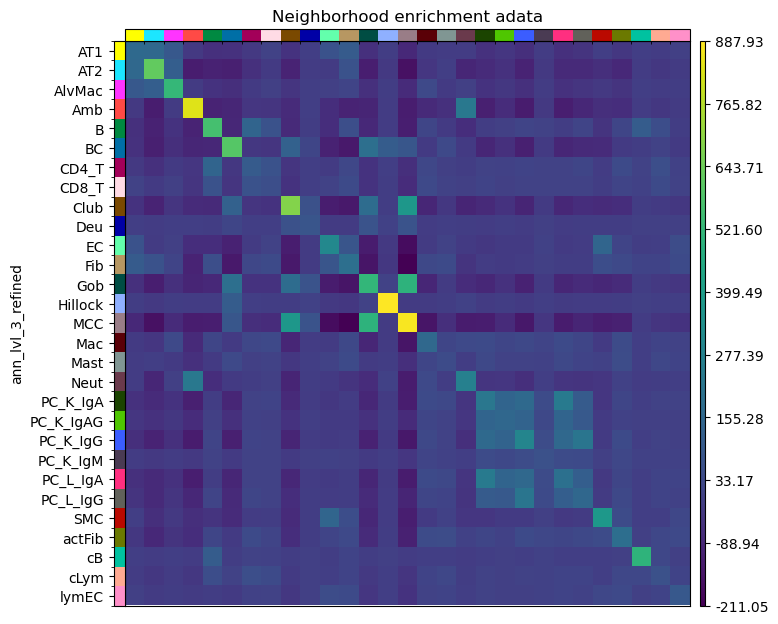

In [9]:

sq.pl.nhood_enrichment(
    comb,
    cluster_key="ann_lvl_3_refined",
    figsize=(6, 6),
    title="Neighborhood enrichment adata",
)
